Params: {'colsample_bytree': np.float64(0.7718264279377748), 'learning_rate': np.float64(0.2182098657218841), 'max_depth': 7, 'alpha': np.float64(0.03), 'eval_metric': 'rmse'}
Train R²: 0.9420605323239596
Test  R²: 0.8249814191159963
Train Pearson: 0.9754570268315607
Test  Pearson: 0.9147135578921148
Train RMSE   : 0.015040419612393862
Test  RMSE   : 0.01734278931258179


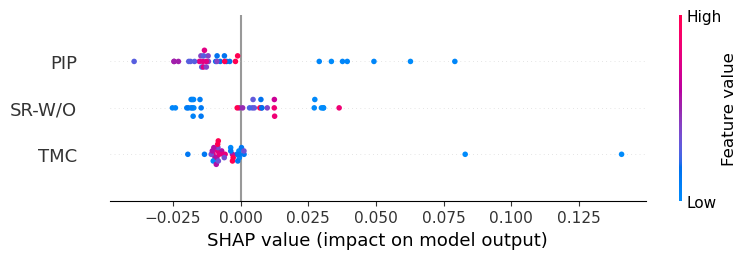

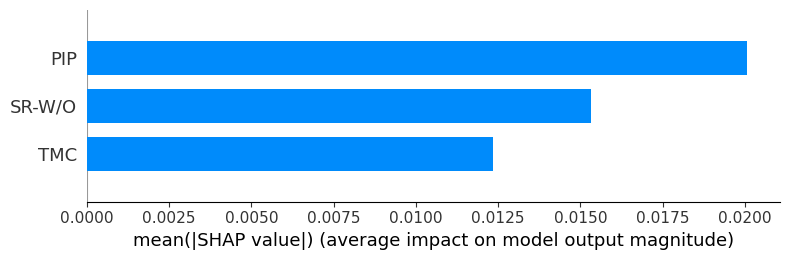

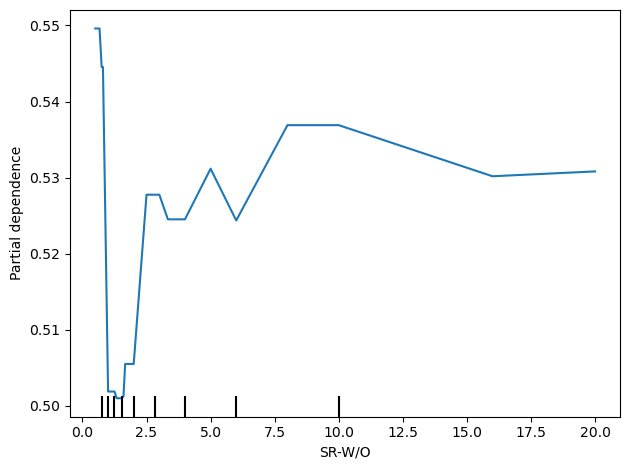

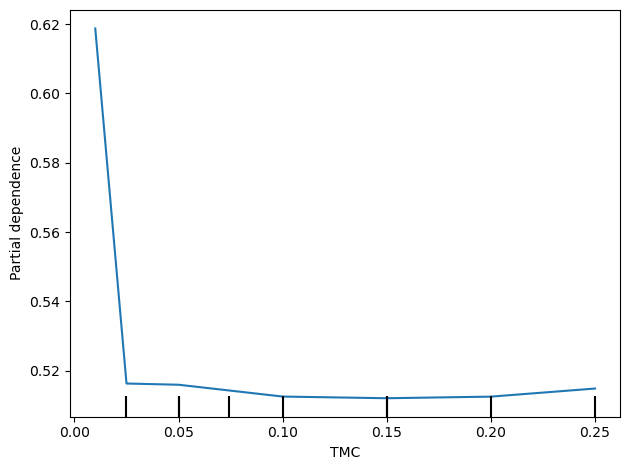

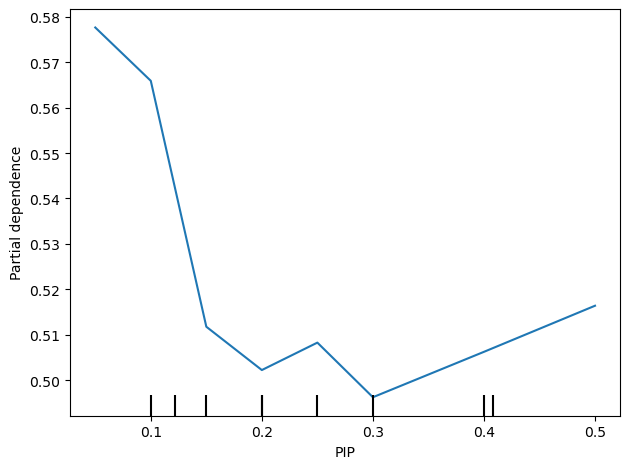

In [7]:
import os
import time
import numpy as np
import pandas as pd
from rdkit import Chem
from scipy.stats import pearsonr
from sklearn import metrics
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from bayes_opt import BayesianOptimization
import shap
import matplotlib.pyplot as plt

# =====================================================================
# 1. Load dataset
# =====================================================================
# Note: this dataset must be obtained from the experimental data
datasets = pd.read_excel('preparation - rp.xlsx')
concatenated = datasets.iloc[:, 2:5]
X = concatenated.to_numpy()
y = datasets.iloc[:, 5]

# =====================================================================
# 2. Train/test split (test set is used only for final evaluation)
# =====================================================================
start_time = time.time()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=108
)


# =====================================================================
# 3. Objective function for Bayesian Optimization
# =====================================================================
def xgb_evaluate(colsample_bytree, learning_rate, max_depth, alpha):
    params = {
        'colsample_bytree': max(min(colsample_bytree, 1), 0),
        'learning_rate':    max(learning_rate, 0.01),
        'max_depth':        int(max_depth),
        'alpha':            max(alpha, 0),
        'eval_metric':      'rmse',
        'n_estimators':     300
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    r2_train = r2_score(y_train, model.predict(X_train))
    r2_test  = r2_score(y_test,  model.predict(X_test))

    # Only accept candidates whose training R^2 is higher than test R^2
    if r2_train > r2_test:
        return r2_test
    else:
        return -1


# =====================================================================
# 4. Search space
# =====================================================================
param_bounds = {
    'colsample_bytree': (0.7, 0.9),
    'learning_rate':    (0.01, 0.3),
    'max_depth':        (7, 10),
    'alpha':            (0.01, 0.03)
}

# =====================================================================
# 5. Run Bayesian Optimization (silent mode)
# =====================================================================
optimizer = BayesianOptimization(
    f=xgb_evaluate,
    pbounds=param_bounds,
    random_state=0,
    verbose=0
)

optimizer.maximize(init_points=5, n_iter=160)

# =====================================================================
# 6. Retrieve best hyperparameters
# =====================================================================
best_params = optimizer.max['params']
best_params['max_depth']   = int(best_params['max_depth'])
best_params['eval_metric'] = 'rmse'

# =====================================================================
# 7. Train the final model with the chosen hyperparameters
# =====================================================================
final_model = XGBRegressor(**best_params, n_estimators=300)
final_model.fit(X_train, y_train)

y_train_pred = final_model.predict(X_train)
y_test_pred  = final_model.predict(X_test)

# ---------- Output: final selected parameters and final model performance ----------
print("Params:", best_params)
print("Train R\u00b2:", r2_score(y_train, y_train_pred))
print("Test  R\u00b2:", r2_score(y_test,  y_test_pred))

# =====================================================================
# 8. Pearson correlation and RMSE 
# =====================================================================
pearson_train, _ = pearsonr(y_train, y_train_pred)
pearson_test,  _ = pearsonr(y_test,  y_test_pred)

rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_train_pred))
rmse_test  = np.sqrt(metrics.mean_squared_error(y_test,  y_test_pred))

print("Train Pearson:", pearson_train)
print("Test  Pearson:", pearson_test)
print("Train RMSE   :", rmse_train)
print("Test  RMSE   :", rmse_test)


# =====================================================================
# 9. Export predictions to Excel
# =====================================================================
output_dir = 'results'
os.makedirs(output_dir, exist_ok=True)

results_train = pd.DataFrame({
    'Actual':    y_train,
    'Predicted': y_train_pred
})
results_test = pd.DataFrame({
    'Actual':    y_test,
    'Predicted': y_test_pred
})

predictions_path = os.path.join(output_dir, 'preparation_rp_predictions.xlsx')
with pd.ExcelWriter(predictions_path) as writer:
    results_train.to_excel(writer, sheet_name='Train', index=False)
    results_test.to_excel(writer,  sheet_name='Test',  index=False)

# =====================================================================
# 10. SHAP analysis
# =====================================================================
feature_names = list(concatenated.columns)
X_train_df    = pd.DataFrame(X_train, columns=feature_names)

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train_df)

# Beeswarm plot
shap.summary_plot(shap_values, X_train_df, feature_names=feature_names)

# Bar plot
shap.summary_plot(shap_values, X_train_df,
                  feature_names=feature_names, plot_type='bar')


# =====================================================================
# 11. Partial Dependence Plots (PDP) and export
# =====================================================================
def export_pdp(model, X_train_df, feature_name, output_dir, file_tag=None):
    """Compute the PDP for a single feature, export it to Excel, and plot it."""
    if feature_name not in X_train_df.columns:
        raise ValueError(
            f"The feature '{feature_name}' is not present in the DataFrame columns."
        )

    disp = PartialDependenceDisplay.from_estimator(
        estimator=model,
        X=X_train_df,
        features=[feature_name],
        kind='average'
    )

    line   = disp.lines_[0][0]
    x_vals = line.get_xdata()
    y_vals = line.get_ydata()

    pdp_df = pd.DataFrame({
        feature_name.strip():  x_vals,
        'Partial Dependence':  y_vals
    })

    # File-system safe tag (avoids '/' in feature names like 'SR-W/O')
    safe_tag = file_tag if file_tag else feature_name.replace('/', '_')
    output_filename = os.path.join(
        output_dir, f'pdp_preparation_rp_{safe_tag}.xlsx'
    )
    pdp_df.to_excel(output_filename, index=False)

    plt.tight_layout()
    plt.show()


# Make sure X_train is a DataFrame with proper column names
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)

export_pdp(final_model, X_train, 'SR-W/O', output_dir, file_tag='SR_WO')
export_pdp(final_model, X_train, 'TMC',    output_dir)
export_pdp(final_model, X_train, 'PIP',    output_dir)